# 02. Popularity Baseline

Во втором notebook мы строим самый простой рекомендатель: он советует объекты, которые чаще всего встречались в train-данных.

## Что изучим

- зачем recommender-проекту нужен baseline;
- как превратить `MovieLens` в задачу top-K рекомендаций;
- как сделать простой split без leakage;
- как обучить popularity-модель и исключить already seen items;
- что такой baseline умеет и где быстро упирается в ограничения.


## Интуиция

`Popularity baseline` отвечает на вопрос: что будет, если вообще не персонализировать рекомендации и просто показывать самые популярные объекты?

Почему это важно:

- это очень простой ориентир, который обязана обыгрывать более сложная модель;
- он быстро показывает, есть ли в пайплайне грубые ошибки;
- он даёт честную нижнюю границу качества и помогает не переоценивать сложные методы.

Важно: baseline не должен притворяться умнее, чем он есть. Это не персонализация, а глобальный список самых частых объектов.


In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero


In [10]:
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import get_movielens_data_dir, load_movielens_frames, build_explicit_interactions
from recsys_basics.split import assert_no_user_time_leakage, leave_last_one_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()

print(f"Interactions loaded: {len(interactions_df):,}")
print(f"Movies loaded: {len(movies_df):,}")


Interactions loaded: 100,836
Movies loaded: 9,742


## Превращаем explicit ratings в положительные события

`MovieLens` содержит explicit ratings от `0.5` до `5.0`. Для top-K baseline мы упростим задачу: будем считать положительным сигналом оценки `>= 4.0`.

Это не означает, что низкие оценки становятся явными негативами. Мы просто строим учебную задачу: какие фильмы пользователь явно оценил достаточно высоко, чтобы считать их релевантными.


In [11]:
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)

conversion_summary = pd.DataFrame(
    {
        "metric": [
            "all_explicit_interactions",
            "positive_interactions",
            "positive_share",
            "users_with_positive_feedback",
            "items_with_positive_feedback",
        ],
        "value": [
            len(interactions_df),
            len(positive_df),
            len(positive_df) / len(interactions_df),
            positive_df["user_id"].nunique(),
            positive_df["item_id"].nunique(),
        ],
    }
)
display(conversion_summary)
display(positive_df.head())


,metric,value
0,all_explicit_interactions,"100,836.0000"
1,positive_interactions,"48,580.0000"
2,positive_share,0.4818
3,users_with_positive_feedback,609.0000
4,items_with_positive_feedback,"6,298.0000"


,user_id,item_id,rating,timestamp,event
0,429,22,4.0000,1996-03-29 18:36:55+00:00,positive_rating
1,429,150,5.0000,1996-03-29 18:36:55+00:00,positive_rating
2,429,161,5.0000,1996-03-29 18:36:55+00:00,positive_rating
3,429,165,4.0000,1996-03-29 18:36:55+00:00,positive_rating
4,429,218,4.0000,1996-03-29 18:36:55+00:00,positive_rating


## Split без leakage

Для каждого пользователя возьмём последнее по времени положительное взаимодействие в `test`, а остальные положительные взаимодействия оставим в `train`.

Это упрощённый вариант `leave-last-one-out`:

- у каждого пользователя должен остаться хотя бы один объект в `train`;
- модель не видит будущее при обучении;
- в `test` у каждого пользователя ровно один релевантный объект.

Важно: в `core` у нас пока нет отдельного `validation`-набора.
Это сознательное упрощение для первых учебных шагов.

Но у такого решения есть граница:
- на таком split удобно сравнивать baseline и первые модели;
- зато серьёзный tuning на тех же данных уже был бы методически неидеален, потому что начал бы опираться на `test`.

В `advanced` мы сделаем схему строже:
- `train`: всё, кроме двух последних positive interactions пользователя;
- `val`: предпоследнее positive interaction;
- `test`: последнее positive interaction.


In [12]:
split_result = leave_last_one_out_split(positive_df, min_user_interactions=2)
train_df = split_result.train
test_df = split_result.test
positive_users = positive_df["user_id"].nunique()
eligible_users = test_df["user_id"].nunique()
dropped_users = positive_users - eligible_users

assert_no_user_time_leakage(train_df, test_df)

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "test_rows",
            "train_users",
            "test_users",
            "train_items",
            "test_items",
            "eligible_users",
            "dropped_users_below_min_interactions",
        ],
        "value": [
            len(train_df),
            len(test_df),
            train_df["user_id"].nunique(),
            test_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            test_df["item_id"].nunique(),
            eligible_users,
            dropped_users,
        ],
    }
)
display(split_summary)

print("Leakage check passed: для каждого пользователя train не позже test.")


,metric,value
0,train_rows,47971
1,test_rows,608
2,train_users,608
3,test_users,608
4,train_items,6263
5,test_items,503
6,eligible_users,608
7,dropped_users_below_min_interactions,1


Leakage check passed: для каждого пользователя train не позже test.


## Обучаем popularity baseline

Модель просто считает, сколько раз каждый `item_id` встретился в `train`, и сортирует объекты по убыванию этой частоты.

На этом этапе никакой персонализации ещё нет.


In [13]:
model = PopularityRecommender().fit(train_df)
seen_items_map = build_seen_items_map(train_df)

top_popular = (
    model.get_popularity_table(top_n=15)
    .merge(movies_df[["item_id", "title", "genres"]], on="item_id", how="left")
)
display(top_popular)


,item_id,popularity_score,title,genres
0,318,271,"Shawshank Redemption, The (1994)",Crime|Drama
1,356,247,Forrest Gump (1994),Comedy|Drama|Romance|War
2,296,242,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,222,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,221,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,199,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,2959,179,Fight Club (1999),Action|Crime|Drama|Thriller
7,527,172,Schindler's List (1993),Drama|War
8,110,166,Braveheart (1995),Action|Drama|War
9,1196,166,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi


## Пример рекомендаций

Теперь посмотрим, как baseline рекомендует фильмы нескольким пользователям. Важно проверить, что рекомендации:

- не содержат уже seen items из train;
- не содержат дубликаты;
- при этом всё ещё строятся из одного глобального popularity ranking.


In [14]:
all_user_ids = sorted(test_df["user_id"].unique().tolist())
user_hit_flags = []
for user_id in all_user_ids:
    recommendations = model.recommend(
        user_id=user_id,
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    test_item_id = int(test_df.loc[test_df["user_id"] == user_id, "item_id"].iloc[0])
    user_hit_flags.append(
        {
            "user_id": int(user_id),
            "test_item_id": test_item_id,
            "hit_at_10": test_item_id in recommendations,
        }
    )

user_hit_flags_df = pd.DataFrame(user_hit_flags)
sample_hit_users = user_hit_flags_df[user_hit_flags_df["hit_at_10"]]["user_id"].head(2).tolist()
sample_miss_users = user_hit_flags_df[~user_hit_flags_df["hit_at_10"]]["user_id"].head(3).tolist()
sample_user_ids = sample_hit_users + sample_miss_users
sample_rows = []

for user_id in sample_user_ids:
    recommendations = model.recommend(
        user_id=user_id,
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    test_item_id = int(test_df.loc[test_df["user_id"] == user_id, "item_id"].iloc[0])
    sample_rows.append(
        {
            "user_id": int(user_id),
            "test_item_id": test_item_id,
            "recommendations": recommendations,
            "n_unique_recommendations": len(set(recommendations)),
            "seen_overlap": len(set(recommendations) & seen_items_map.get(int(user_id), set())),
            "hit_at_10": test_item_id in recommendations,
        }
    )

sample_recommendations_df = pd.DataFrame(sample_rows)
display(sample_recommendations_df)

for user_id in sample_user_ids[:3]:
    recommendations = model.recommend(
        user_id=user_id,
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    ranked_recommendations = pd.DataFrame(
        {
            "rank": range(1, len(recommendations) + 1),
            "item_id": recommendations,
        }
    ).merge(movies_df[["item_id", "title", "genres"]], on="item_id", how="left")
    test_item_id = int(test_df.loc[test_df["user_id"] == user_id, "item_id"].iloc[0])
    print(f"User {user_id} | held-out test item: {test_item_id}")
    display(ranked_recommendations)


,user_id,test_item_id,recommendations,n_unique_recommendations,seen_overlap,hit_at_10
0,36,318,"[318, 356, 296, 593, 2571, 260, 2959, 527, 110...",10,0,True
1,54,356,"[356, 296, 2571, 260, 2959, 527, 110, 1196, 50...",10,0,True
2,1,2492,"[318, 296, 858, 589, 4993, 7153, 5952, 150, 27...",10,0,False
3,2,80489,"[318, 356, 296, 593, 2571, 260, 2959, 527, 110...",10,0,False
4,3,3024,"[318, 356, 296, 593, 2571, 260, 2959, 527, 110...",10,0,False


User 36 | held-out test item: 318


,rank,item_id,title,genres
0,1,318,"Shawshank Redemption, The (1994)",Crime|Drama
1,2,356,Forrest Gump (1994),Comedy|Drama|Romance|War
2,3,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,4,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,5,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,6,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,7,2959,Fight Club (1999),Action|Crime|Drama|Thriller
7,8,527,Schindler's List (1993),Drama|War
8,9,110,Braveheart (1995),Action|Drama|War
9,10,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi


User 54 | held-out test item: 356


,rank,item_id,title,genres
0,1,356,Forrest Gump (1994),Comedy|Drama|Romance|War
1,2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,3,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
3,4,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
4,5,2959,Fight Club (1999),Action|Crime|Drama|Thriller
5,6,527,Schindler's List (1993),Drama|War
6,7,110,Braveheart (1995),Action|Drama|War
7,8,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
8,9,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
9,10,1198,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure


User 1 | held-out test item: 2492


,rank,item_id,title,genres
0,1,318,"Shawshank Redemption, The (1994)",Crime|Drama
1,2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2,3,858,"Godfather, The (1972)",Crime|Drama
3,4,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
4,5,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
5,6,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy
6,7,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
7,8,150,Apollo 13 (1995),Adventure|Drama|IMAX
8,9,2762,"Sixth Sense, The (1999)",Drama|Horror|Mystery
9,10,4226,Memento (2000),Mystery|Thriller


## Простой sanity-check качества

Подробные метрики мы разберём позже, но для baseline полезно уже сейчас посчитать один очень простой показатель.

Так как в `test` у каждого пользователя ровно один релевантный фильм, `HitRate@K` здесь читается просто:

- `1`, если hidden test item попал в top-K рекомендаций;
- `0`, если не попал.

Среднее по пользователям показывает, для какой доли пользователей baseline сумел угадать хотя бы один релевантный объект.


,metric,value
0,HitRate@10,3.95%
1,unique_recommended_items,61
2,catalog_coverage,0.97%


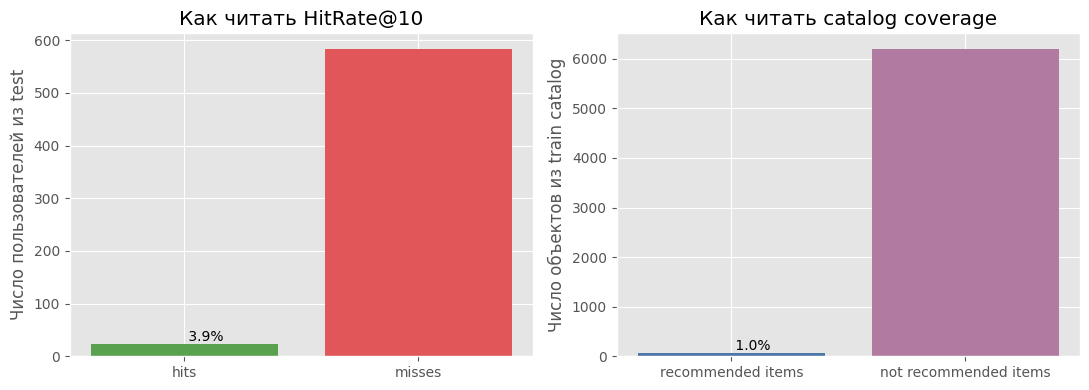

In [15]:
def hit_rate_at_k(test_interactions: pd.DataFrame, recommendations: pd.DataFrame, k: int) -> float:
    top_k = recommendations[recommendations["rank"] <= k]
    merged = test_interactions[["user_id", "item_id"]].merge(
        top_k,
        on=["user_id", "item_id"],
        how="left",
    )
    hits = merged["rank"].notna().mean()
    return float(hits)


recommendations_df = model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)

hit_rate_10 = hit_rate_at_k(test_df, recommendations_df, k=TOP_K)
unique_recommended_items = recommendations_df["item_id"].nunique()
catalog_coverage = unique_recommended_items / train_df["item_id"].nunique()
hit_count = int(round(hit_rate_10 * len(test_df)))
miss_count = len(test_df) - hit_count
not_recommended_train_items = train_df["item_id"].nunique() - unique_recommended_items

evaluation_summary = pd.DataFrame(
    {
        "metric": ["HitRate@10", "unique_recommended_items", "catalog_coverage"],
        "value": [f"{hit_rate_10:.2%}", unique_recommended_items, f"{catalog_coverage:.2%}"],
    }
)
display(evaluation_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["hits", "misses"], [hit_count, miss_count], color=["#59A14F", "#E15759"])
axes[0].set_title("Как читать HitRate@10")
axes[0].set_ylabel("Число пользователей из test")
axes[0].text(0, hit_count, f" {hit_rate_10:.1%}", va="bottom")

axes[1].bar(["recommended items", "not recommended items"], [unique_recommended_items, not_recommended_train_items], color=["#4C78A8", "#B07AA1"])
axes[1].set_title("Как читать catalog coverage")
axes[1].set_ylabel("Число объектов из train catalog")
axes[1].text(0, unique_recommended_items, f" {catalog_coverage:.1%}", va="bottom")
for tick in axes[1].get_xticklabels():
    tick.set_rotation(0)

plt.tight_layout()
plt.show()


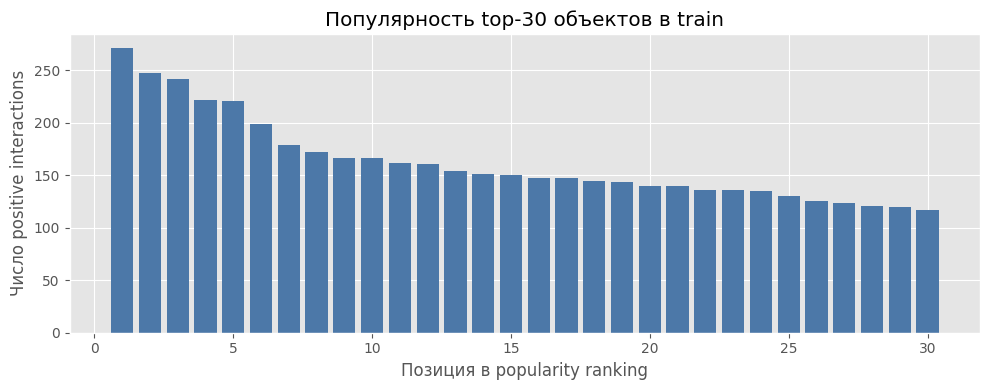

In [16]:
popularity_hist = model.get_popularity_table(top_n=30)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(popularity_hist) + 1), popularity_hist["popularity_score"], color="#4C78A8")
ax.set_title("Популярность top-30 объектов в train")
ax.set_xlabel("Позиция в popularity ranking")
ax.set_ylabel("Число positive interactions")
plt.tight_layout()
plt.show()


## Ограничения метода

У popularity baseline сразу видны важные слабые стороны:

- он почти не персонализирует выдачу;
- он тяготеет к head-объектам и усиливает popularity bias;
- coverage каталога обычно низкое;
- cold-start для новых или нишевых объектов почти не решается.

Но именно поэтому baseline полезен: если более сложная модель не даёт заметного выигрыша относительно такой простой отправной точки, это повод проверить данные, split и постановку задачи.


## Что получилось

После этого notebook должно быть понятно:

- как из explicit ratings получить учебную top-K постановку;
- почему baseline обязателен перед любыми более сложными моделями;
- как сделать честный `leave-last-one-out` split без leakage;
- почему в `core` пока используется только `train/test`, без отдельного `val`;
- почему даже такой удобный split уже не идеален для серьёзного tuning и будет ужесточён в `advanced`;
- как popularity recommender фильтрует already seen items;
- почему даже рабочий baseline быстро упирается в отсутствие персонализации.

## Что дальше

Следующий шаг: [03_content_based_tfidf.ipynb](../../notebooks/basic/03_content_based_tfidf.ipynb). Там мы начнём использовать признаки самих объектов и посмотрим, как выйти за пределы чистой popularity-логики.
